# Tutorial 11: Models and Machinery

Every previous tutorial used the defaults and said little about them. This one
opens the box: the bound the estimator is built on and the ceiling that comes
with it, the second estimator that does not have that ceiling, how to tell a
real result from a lucky one, and which architecture to point at your data.

The order matters. The ceiling is first because it is the failure that silently
caps a result and looks like a finding.

1. The InfoNCE ceiling, and why a number can be pinned to your batch size.
2. SMILE, which trades the ceiling for variance.
3. Permutation nulls, and computing a p-value that means something.
4. The ten architectures, graded against an exact answer.
5. Supplying your own, and the input convention it has to declare.

## 0. Setup

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import neural_mi as nmi
from neural_mi.generators.oracle import SharedLatentGaussian

SCALE = 1
np.random.seed(0)
print("estimators :", sorted(nmi.estimators.ESTIMATORS))

estimators : ['infonce', 'smile']


## 1. The InfoNCE ceiling

InfoNCE scores a matched pair against a set of mismatched ones and asks the
critic to pick the true partner out of the lineup. That framing is what makes it
trainable, and it is also what caps it: identifying the right partner among `K`
candidates can carry at most `log2(K)` bits of evidence, no matter how much
information the variables actually share.

In this library `K` is the batch during training and `max_eval_samples` at
evaluation. Set both small and the cap becomes visible.

We use data with a genuinely high true MI of 8 bits, so the ceiling is the
binding constraint rather than the data.

In [2]:
TRUE_HIGH = 8.0
xh, yh = nmi.generators.generate_correlated_gaussians(
    n_samples=int(6000 * SCALE), dim=8, mi=TRUE_HIGH)

rows = []
t0 = time.time()
for bs in (16, 32, 64, 256):
    r = nmi.run(xh, yh, mode='estimate', split=nmi.Split(mode='random'),
                training=nmi.Training(n_epochs=int(40 * SCALE), patience=15,
                                      batch_size=bs, max_eval_samples=bs),
                model=nmi.Model(embedding_dim=32, hidden_dim=128),
                n_workers=1, seed=0, show_progress=False)
    rows.append((bs, r.mi_estimate, np.log2(bs),
                 r.details['test_ceiling_mi'], r.details['test_saturation']))
    print(f"  batch={bs:>4}   MI = {r.mi_estimate:5.3f}   log2(batch) = {np.log2(bs):4.2f}   "
          f"reported ceiling = {r.details['test_ceiling_mi']:4.2f}   "
          f"saturation = {r.details['test_saturation']:.3f}")

print(f"\ntrue MI = {TRUE_HIGH} bits   ({time.time() - t0:.0f}s)")

2026-08-26 16:00:05 - neural_mi - WARNING - InfoNCE estimate is near its ceiling: test MI (3.804 bits) vs. test ceiling log(test_eval_size=16)=4.000 bits; reported train MI (3.885 bits) vs. train-eval ceiling log(train_eval_size=16)=4.000 bits. The true MI may be higher. Consider increasing max_eval_samples (and train_subset_size, if set) or switching to the 'smile' estimator for high-MI scenarios.


2026-08-26 16:00:05 - neural_mi - WARNING - Peak-epoch selection may be unreliable: 96% of the smoothed test-MI history sits above 90% of the test ceiling (4.000 bits). With the trace riding near its ceiling, the epoch with the (noisy) maximum is close to arbitrary. Consider increasing max_eval_samples.


  batch=  16   MI = 3.885   log2(batch) = 4.00   reported ceiling = 4.00   saturation = 0.951


2026-08-26 16:00:37 - neural_mi - WARNING - InfoNCE estimate is near its ceiling: test MI (4.713 bits) vs. test ceiling log(test_eval_size=32)=5.000 bits; reported train MI (4.893 bits) vs. train-eval ceiling log(train_eval_size=32)=5.000 bits. The true MI may be higher. Consider increasing max_eval_samples (and train_subset_size, if set) or switching to the 'smile' estimator for high-MI scenarios.


neural_mi/analysis/task.py:367: UserWarning: Training completed all 40 epoch(s) without early stopping, and the best (smoothed) test MI occurred at the final epoch. MI may still have been increasing when training stopped, so the reported estimate could be an under-trained lower bound. Consider increasing n_epochs (or lowering patience to enable early stopping).
  results = trainer.train(


  batch=  32   MI = 4.893   log2(batch) = 5.00   reported ceiling = 5.00   saturation = 0.943


2026-08-26 16:00:47 - neural_mi - WARNING - InfoNCE estimate is near its ceiling: reported train MI (5.411 bits) vs. train-eval ceiling log(train_eval_size=64)=6.000 bits. The true MI may be higher. Consider increasing max_eval_samples (and train_subset_size, if set) or switching to the 'smile' estimator for high-MI scenarios.


  batch=  64   MI = 5.411   log2(batch) = 6.00   reported ceiling = 6.00   saturation = 0.807


  batch= 256   MI = 6.402   log2(batch) = 8.00   reported ceiling = 8.00   saturation = 0.797

true MI = 8.0 bits   (94s)


**The estimate tracks the ceiling, not the truth.** At every batch size the
answer lands just under `log2(batch_size)`, and the true 8 bits is nowhere in
sight until the ceiling clears it.

`test_ceiling_mi` is the library reporting `log2` of the number of evaluation
samples it actually used, and `test_saturation` is the fraction of that ceiling
your estimate reached. Saturation approaching 1 means the number you are reading
is a property of your batch size.

**This is the most dangerous failure mode in the library**, because nothing
looks wrong. Training converges, the loss is healthy, the estimate is stable
across seeds, and it is still meaningless. The only symptom is high saturation.

The remedy is a larger batch and a larger `max_eval_samples`, which costs memory
rather than accuracy. Check saturation before believing any large MI value.

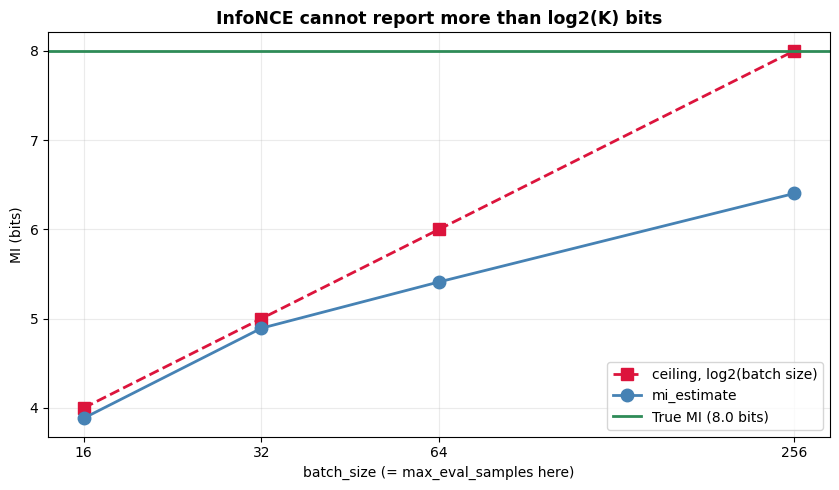

In [3]:
bs_arr = np.array([r[0] for r in rows])
mi_arr = np.array([r[1] for r in rows])
ceil_arr = np.array([r[2] for r in rows])

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(bs_arr, ceil_arr, 's--', color='crimson', lw=2, ms=9,
        label='ceiling, log2(batch size)')
ax.plot(bs_arr, mi_arr, 'o-', color='steelblue', lw=2, ms=9, label='mi_estimate')
ax.axhline(TRUE_HIGH, color='seagreen', lw=2, label=f'True MI ({TRUE_HIGH} bits)')
ax.set_xscale('log', base=2)
ax.set_xticks(bs_arr)
ax.set_xticklabels([str(b) for b in bs_arr])
ax.set_xlabel('batch_size (= max_eval_samples here)')
ax.set_ylabel('MI (bits)')
ax.set_title('InfoNCE cannot report more than log2(K) bits',
             fontsize=12.5, fontweight='bold')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 2. SMILE, which has no such cap

`smile` clips the density-ratio estimate instead of relying on a lineup, so it
is not bounded by `log2(K)`. The `clip` parameter sets how far the log-ratio may
travel; larger admits more signal and more variance.

Run both at the same deliberately small batch of 32, where InfoNCE is capped at
5 bits and the truth is 8.

In [4]:
for name, est in [('infonce', nmi.Estimator(name='infonce')),
                  ('smile',   nmi.Estimator(name='smile', params={'clip': 5.0}))]:
    t0 = time.time()
    r = nmi.run(xh, yh, mode='estimate', split=nmi.Split(mode='random'),
                training=nmi.Training(n_epochs=int(40 * SCALE), patience=15,
                                      batch_size=32, max_eval_samples=32),
                model=nmi.Model(embedding_dim=32, hidden_dim=128),
                estimator=est, n_workers=1, seed=0, show_progress=False)
    print(f"  {name:<9} MI = {r.mi_estimate:.3f} bits   ({time.time() - t0:.0f}s)")

print(f"\n  InfoNCE ceiling at batch 32 = {np.log2(32):.1f} bits")
print(f"  true MI                     = {TRUE_HIGH} bits")

2026-08-26 16:01:24 - neural_mi - WARNING - InfoNCE estimate is near its ceiling: test MI (4.713 bits) vs. test ceiling log(test_eval_size=32)=5.000 bits; reported train MI (4.893 bits) vs. train-eval ceiling log(train_eval_size=32)=5.000 bits. The true MI may be higher. Consider increasing max_eval_samples (and train_subset_size, if set) or switching to the 'smile' estimator for high-MI scenarios.


neural_mi/analysis/task.py:367: UserWarning: Training completed all 40 epoch(s) without early stopping, and the best (smoothed) test MI occurred at the final epoch. MI may still have been increasing when training stopped, so the reported estimate could be an under-trained lower bound. Consider increasing n_epochs (or lowering patience to enable early stopping).
  results = trainer.train(


  infonce   MI = 4.893 bits   (33s)


2026-08-26 16:01:59 - neural_mi - WARNING - Peak-epoch selection may be unreliable: 100% of the smoothed test-MI history sits above 90% of the test ceiling (5.000 bits). With the trace riding near its ceiling, the epoch with the (noisy) maximum is close to arbitrary. Consider increasing max_eval_samples.


  smile     MI = 6.836 bits   (35s)

  InfoNCE ceiling at batch 32 = 5.0 bits
  true MI                     = 8.0 bits


**SMILE clears the InfoNCE ceiling**, which is the point of it. It still falls
short of the truth, because clipping trades bias for variance rather than
removing the problem.

Use `infonce` by default: it is stable, well understood, and its ceiling is
predictable and reportable. Reach for `smile` when saturation says you are
against the ceiling and you cannot afford a larger batch. Do not reach for it to
make a number bigger; a higher estimate is not automatically a better one, and
SMILE's variance is the price.

## 3. Telling a real result from a lucky one

A permutation null breaks the pairing between X and Y, re-runs the whole
pipeline, and asks what the machinery returns when there is nothing to find.
Anything your pipeline manufactures shows up here.

Two datasets: one with a real 1 bit of coupling, one with none at all.

Note `n_workers=8`. The permutations are independent runs and the library fans
them across a process pool, which is the difference between half a minute and
several. In a `.py` script rather than a notebook this needs the usual
`if __name__ == '__main__':` guard, because the pool spawns.

In [5]:
N_PERM = int(50 * SCALE)

for label, true_mi in [('real coupling', 1.0), ('no coupling', 0.0)]:
    if true_mi > 0:
        xp, yp = nmi.generators.generate_correlated_gaussians(
            n_samples=3000, dim=4, mi=true_mi)
        xp, yp = np.asarray(xp, 'float32'), np.asarray(yp, 'float32')
    else:
        rng = np.random.default_rng(0)
        xp = rng.normal(size=(3000, 4)).astype('float32')
        yp = rng.normal(size=(3000, 4)).astype('float32')

    t0 = time.time()
    r = nmi.run(xp, yp, mode='estimate', split=nmi.Split(mode='random'),
                training=nmi.Training(n_epochs=int(30 * SCALE), patience=12),
                model=nmi.Model(embedding_dim=8, hidden_dim=64),
                permutation_test=True, n_permutations=N_PERM,
                n_workers=8, seed=0, show_progress=False)

    null = np.array([float(v) for v in r.details['null_distribution']])
    # the standard permutation p-value, which counts the observed value itself
    p = (1 + np.sum(null >= r.mi_estimate)) / (1 + len(null))
    print(f"  {label:<15} true={true_mi}  MI={r.mi_estimate:.4f}  "
          f"null mean={null.mean():.4f}  null max={null.max():.4f}  "
          f"p={p:.3f}   ({time.time() - t0:.0f}s)")

2026-08-26 16:01:59 - neural_mi - WARNING - Reproducibility with random_seed is not guaranteed with n_workers > 1.


neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0002 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0006 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(


neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0000 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0003 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(
neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0002 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0002 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results =

neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0003 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0004 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(
neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0004 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0003 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results =

neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0008 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0004 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(
neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0003 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0002 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results =

...

neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0003 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0005 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(


neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0002 nats at epoch 3). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0035 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(
neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0001 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0002 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results =

neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0003 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0005 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(


neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0004 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0002 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(


  no coupling     true=0.0  MI=0.0239  null mean=0.0041  null max=0.0305  p=0.059   (33s)


**The uncoupled case does not return zero.** It returns a small positive number,
because the estimator is a maximisation over a flexible critic and a flexible
critic can always find some apparent structure in finite noise. The null
distribution is what tells you that number is nothing.

**Compute the p-value yourself.** The library returns the null in
`details['null_distribution']` and does not compute a p-value for you. The
standard permutation estimate is

```
p = (1 + #{null >= observed}) / (1 + n_permutations)
```

The leading `1` in each term counts the observed value among the possibilities,
which keeps `p` from ever being exactly zero: with 50 permutations the smallest
attainable value is `1/51`, about 0.02. If you need to report `p < 0.01` you
need at least 100 permutations, and that is the real reason for the count rather
than any property of the estimator.

Note that `n_workers > 1` makes the individual null values non-reproducible even
with `seed` set, which the library warns about. The conclusion survives that:
the question is whether the observed value sits outside the null, not what the
third permutation happened to return.

## 4. Which architecture

Ten embedding models ship. The honest way to compare them is against an exact
answer, so we use the Gaussian oracle, whose block MI at a given window is known
in closed form.

In [6]:
W = 8
orc = SharedLatentGaussian(dims={'x': 4, 'y': 4}, d=1, phi=0.95,
                           noise=1.0, coupling=1.0, seed=0)
EXACT = orc.block_mi(W)
s = orc.sample(int(20000 * SCALE), seed=1)
xs, ys = s['x'].astype('float32'), s['y'].astype('float32')

proc = nmi.Processing(x='continuous', x_params={'window_size': W, 'step_size': W},
                      y='continuous', y_params={'window_size': W, 'step_size': W})
TRAIN = nmi.Training(n_epochs=int(80 * SCALE), patience=25, batch_size=256)

print(f"exact block MI at window={W}: {EXACT:.4f} bits\n")
print(f"  {'architecture':<14}{'MI':>8}{'error':>9}{'secs':>7}")
arch_results = {}
for arch in ('mlp', 'cnn', 'gru', 'lstm', 'lru', 'tcn', 'transformer'):
    extra = {'nhead': 4} if arch == 'transformer' else {}
    t0 = time.time()
    r = nmi.run(xs, ys, mode='estimate', processing=proc, training=TRAIN,
                model=nmi.Model(embedding_model=arch, embedding_dim=16,
                                hidden_dim=64, **extra),
                n_workers=1, seed=0, show_progress=False)
    arch_results[arch] = r.mi_estimate
    print(f"  {arch:<14}{r.mi_estimate:>8.3f}{r.mi_estimate - EXACT:>+9.3f}"
          f"{time.time() - t0:>7.1f}")

exact block MI at window=8: 4.0021 bits

  architecture        MI    error   secs


neural_mi/analysis/task.py:367: UserWarning: Training completed all 80 epoch(s) without early stopping, and the best (smoothed) test MI occurred at the final epoch. MI may still have been increasing when training stopped, so the reported estimate could be an under-trained lower bound. Consider increasing n_epochs (or lowering patience to enable early stopping).
  results = trainer.train(


  mlp              3.266   -0.736    4.2


  cnn              2.882   -1.120    3.9


  gru              3.228   -0.774   11.0


  lstm             3.140   -0.862    4.7


  lru              3.051   -0.951   17.9


  tcn              3.241   -0.761    5.4


  transformer      3.030   -0.973   14.0


**Every one of them undershoots**, which is the expected behaviour: these are
variational lower bounds, so falling short is the honest direction to fail in.

The spread between them is larger than most people expect, and that is the
useful lesson. Architecture is a real experimental variable here, not a detail
to leave at its default. Note also that the sequence-aware models do not
automatically beat the plain `mlp` on this data.

Two remaining models are not in the table. `cnn2d` expects 4-D image-shaped
input, and `pretrained_backbone` loads ImageNet weights and earns its cost on
image data, so neither suits a 4-channel time series. `dual_branch` is a
composite used by the rate quantities in Tutorial 5.

## 5. Bringing your own

A custom embedding needs to tell the library what shape it expects. That is what
`input_style` is for, declared on the class itself:

- `input_style = 'flattened'` (the `BaseEmbedding` default) receives
  `input_dim = n_channels * window_size`, one flat vector per window.
- `input_style = 'channels'` receives `input_dim = n_channels` and keeps the
  time axis, which is what the sequence models use.

The class declares its own convention, so nothing else has to be configured to
match it.

In [7]:
import torch
import torch.nn as nn
from neural_mi.models.embeddings import BaseEmbedding

class GatedConvEmbedding(BaseEmbedding):
    input_style = 'channels'          # give me (batch, n_channels, window)

    def __init__(self, input_dim, hidden_dim, embed_dim, n_layers=1, **kwargs):
        super().__init__()
        self.conv = nn.Conv1d(input_dim, hidden_dim, 3, padding=1)
        self.gate = nn.Conv1d(input_dim, hidden_dim, 3, padding=1)
        self.head = nn.Sequential(nn.Flatten(), nn.LazyLinear(embed_dim))

    def forward(self, x):
        return self.head(torch.tanh(self.conv(x)) * torch.sigmoid(self.gate(x)))

print(f"at window={W} with 4 channels:")
print(f"  input_style='channels'   -> input_dim = 4")
print(f"  input_style='flattened'  -> input_dim = {4 * W}")

t0 = time.time()
r = nmi.run(xs, ys, mode='estimate', processing=proc, training=TRAIN,
            model=nmi.Model(custom_embedding_cls=GatedConvEmbedding,
                            embedding_dim=16, hidden_dim=64),
            n_workers=1, seed=0, show_progress=False)
print(f"\n  custom          {r.mi_estimate:>8.3f}{r.mi_estimate - EXACT:>+9.3f}"
      f"{time.time() - t0:>7.1f}")
print(f"  best shipped    {max(arch_results.values()):>8.3f}"
      f"{max(arch_results.values()) - EXACT:>+9.3f}")

at window=8 with 4 channels:
  input_style='channels'   -> input_dim = 4
  input_style='flattened'  -> input_dim = 32



  custom             3.871   -0.131    3.0
  best shipped       3.266   -0.736


The custom class comes out ahead of every shipped model here, and the reason is
worth understanding rather than celebrating.

**It keeps the time axis.** `GRU` returns only its final hidden state
(`_, h_n = self.gru(x)`) and `CNN1D` applies an adaptive average pool, so both
compress the window to a single vector before the embedding head. This class
flattens every timestep into the head instead. On an AR(1)-driven signal, where
which timestep something happened in carries information, that difference
matters.

So the lesson is not that gated convolutions are good. It is that **the pooling
step is a modelling decision**, and the shipped defaults make a reasonable
choice that happens to be wrong for this data. If your estimate is lower than
you expect and the ceiling is not the cause, how the architecture reduces over
time is the next place to look.

## Key Takeaways

- InfoNCE cannot report more than `log2(K)` bits, where `K` is the batch during
  training and `max_eval_samples` at evaluation. Check `test_saturation` before
  believing any large value.
- A saturated estimate looks completely healthy. Nothing else signals it.
- `smile` is not bounded by `log2(K)` and pays for it in variance. Use it when
  saturation forces you to, not to make a number larger.
- An uncoupled dataset returns a small positive MI. A permutation null is what
  establishes that it is nothing.
- The library gives you `details['null_distribution']`, not a p-value. Compute
  `p = (1 + #{null >= observed}) / (1 + n_permutations)`. With 50 permutations
  the smallest attainable p is about 0.02.
- Permutations parallelise across `n_workers`, which is the difference between
  seconds and minutes.
- Architectures differ by more than you would guess, and all of them undershoot.
  Sequence models do not automatically beat an MLP.
- A custom class declares `input_style` and nothing else needs configuring.

## Common Mistakes

1. **Reading a large MI without checking saturation.** If `test_saturation` is
   near 1 you measured your batch size.
2. **Raising `batch_size` but leaving `max_eval_samples` small.** The evaluation
   ceiling then binds instead, and the symptom is identical.
3. **Switching to SMILE because the number goes up.** It goes up partly because
   the variance went up. Switch when saturation justifies it.
4. **Treating a small positive MI as weak evidence of coupling.** Uncoupled data
   returns a small positive MI. Run the null.
5. **Quoting `p = 0`.** A permutation p-value has a floor of `1/(1 + n_perm)`.
6. **Running permutations with `n_workers=1`.** They are independent; fan them
   out. In a script, remember the `if __name__ == '__main__':` guard.
7. **Leaving the architecture at its default and blaming the data.** How the
   model reduces over the time axis is a real modelling choice.

## What's Next

That is the series. Tutorials 0 and 1 covered what an estimate means and how to get one; 2 and 3 covered getting real data into shape and splitting it honestly; 4 through 6 covered choosing the quantity that matches your question; 7 and 8 covered defending a result and adding a third variable; 9 and 10 worked two real recordings end to end, where no ground truth exists and the controls carry the claims; and this one covered the machinery underneath.

For the full API surface see `NEURALMI_REFERENCE.md`, and for the derivations
behind the quantities see `THEORY.md`.